In [1]:
# Aluno: Nicholas Barbosa e Costa
# Matrícula: 95667

import cv2 as cv
import numpy as np
import random
import matplotlib.pyplot as plt

image = cv.imread("anitta.png")
imageGray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
cv.imwrite("anitta-gray.png", imageGray);

In [2]:
# Função que printa uma imagem com título

def show_image(image, title):
    if len(image.shape) == 2: 
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    
    plt.title(title)
    plt.axis('off')

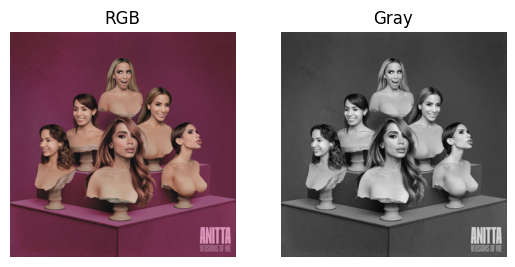

In [3]:
# Cria uma grid 1x2
# Plota imageRgb na primeira posição
plt.subplot(1, 2, 1)
show_image(image, "RGB")

# Plota imageGray na segunda posição
plt.subplot(1, 2, 2)
show_image(imageGray, "Gray")

plt.show()

Number of keypoints: 300


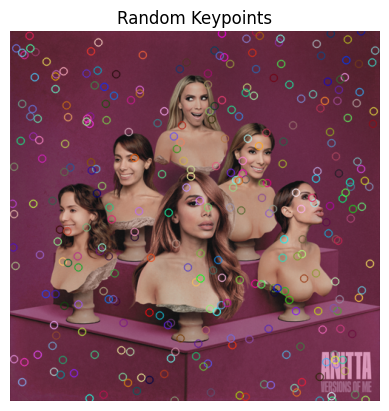

In [4]:
# Keypoints aleatórios

kps_random = []

img_height = imageGray.shape[0]
img_width = imageGray.shape[1]

for i in range(300):
    x = random.randint(0, img_width - 1)
    y = random.randint(0, img_height - 1)
    kps_random.append(cv.KeyPoint(x, y, 10))

output_random = cv.drawKeypoints(image,
                                 kps_random,
                                 np.array([]),
                                 flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_image(output_random, "Random Keypoints")

print('Number of keypoints:', len(kps_random))

Number of keypoints: 225


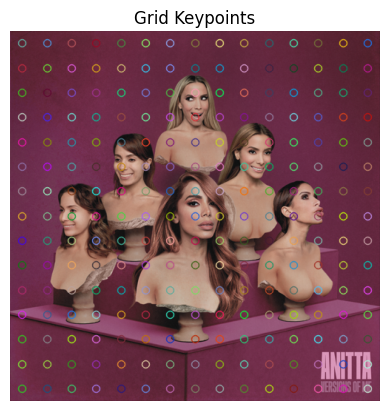

In [5]:
# Grid keypoints
kps_grid = []

cell_width = img_width / 15
cell_height = img_height / 15

for i in range(15):
    for j in range(15):
        x = int((i + 0.5) * cell_width)
        y = int((j + 0.5) * cell_height)
        kps_grid.append(cv.KeyPoint(x, y, 10))

output_grid = cv.drawKeypoints(image,
                               kps_grid,
                               np.array([]),
                               flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show_image(output_grid, "Grid Keypoints")

print('Number of keypoints:', len(kps_grid))

Descriptor size of the first keypoint: 128
Descriptor of the first keypoint:
 [  1.   1.   1.   0.   1.   1.   3.   3.   7.   2.   5.   1.   0.   0.
   2.   6.  68.   2.   1.   0.   0.   0.   0. 157.  59.   0.   0.   0.
   0.   0.   5. 168.   0.   1.  53.  27.   1.   0.   0.   0.  52.  21.
  76.  27.   0.   0.   0.   3. 168.  21.   8.   1.   0.   0.   0. 137.
  92.  17.  12.   0.   0.   0.   0.  80.   0.   1.  74.  35.   0.   0.
   0.   0. 125.  34.  46.  13.   0.   0.   0.   1. 168.  77.   2.   0.
   0.   0.   0.  14.  54.  56.  25.   0.   0.   0.   0.   2.   0.   5.
   8.   1.   0.   0.   0.   0.  62.  38.   4.   0.   0.   0.   0.   0.
 168. 136.   0.   0.   0.   0.   0.   3.  73.  29.   2.   0.   0.   0.
  16.  22.]


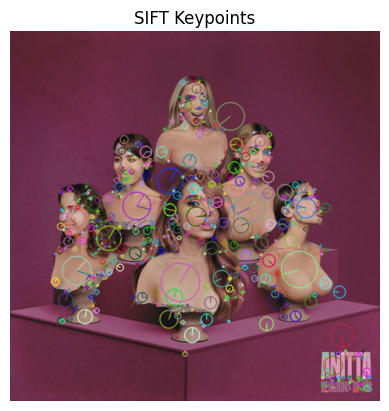

In [6]:
# Detectando keypoints com SIFT

sift = cv.SIFT_create()

kps_sift = sift.detect(imageGray, None)


if len(kps_sift) > 0:
    # Descritor SIFT

    # o sift.compute() retorna (keypoints, descritores)
    # os keypoints podem ser reajustados, se houver necessidade
    kps_sift , descriptors_sift = sift.compute(imageGray, kps_sift)

    # printa o tamanho do descritor do primeiro keypoint
    print(f"Descriptor size of the first keypoint: {len(descriptors_sift[0])}")

    # printa o descritor do primeiro keypoint
    print(f"Descriptor of the first keypoint:\n {descriptors_sift[0]}")

    output_sift = cv.drawKeypoints(image,
                                   kps_sift,
                                   np.array([]),
                                   flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    show_image(output_sift, "SIFT Keypoints")

else:
    print('No keypoints found.')


Descriptor size of the first keypoint: 128
Descriptor of the first keypoint:
 [ 35.  26.  10.  12.  25.  27.  26.  29.  40.  44.  49.  37. 104.  71.
  31.  18.  70.  34.  68.  61.  21.  27. 104.  52.  24.  35.  45.  44.
  34.  70.  60.  68.  30.  59.  82.  50.  30.  22.  24.  27.  58.  42.
  75.  94.  72.  57.  62.  43. 104.  72.  89.  46.  52.  67.  79.  82.
  24.  40.  48.  69.  58.  60.  17.  22.   5.   6.  25.  16.   6.   5.
   8.   7.  90.  56.  52.  38.  38.  55.  33.  30.  70.  57.  73.  77.
  71.  41.  29.  36.  62.  43.  40.  59.  50.  29.  23.  48.   3.   3.
   2.   1.   1.   1.   2.   3.   5.   5.   6.   4.   2.   6.   7.   4.
   6.   5.   5.   4.   3.   3.   5.   5.  16.  18.  16.   9.  10.  23.
  10.  15.]


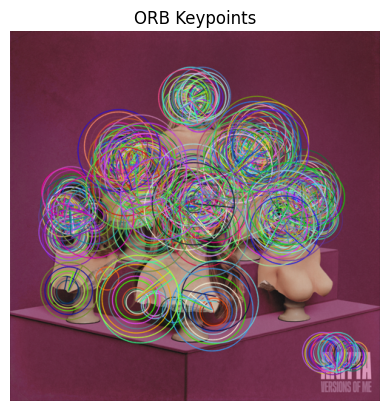

In [7]:
# Detectando keypoints com ORB

orb = cv.ORB_create()

kps_orb = orb.detect(imageGray, None)

if len(kps_orb) > 0:
    # Descritor usando SIFT sobre keypoints do ORB
    
    kps_orb, descriptors = sift.compute(imageGray, kps_orb)

    # printa o tamanho do descritor do primeiro keypoint
    print(f"Descriptor size of the first keypoint: {len(descriptors[0])}")

    # printa o descritor do primeiro keypoint
    print(f"Descriptor of the first keypoint:\n {descriptors[0]}")

    output_orb = cv.drawKeypoints(image,
                                  kps_orb,
                                  np.array([]),
                                  flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    show_image(output_orb, "ORB Keypoints")
   
else:
    print('No keypoints found.')